In [2]:
# ============================================
# STEP 2: Import Libraries
# ============================================
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [4]:
documents = [
    "Artificial intelligence is transforming the world with automation and smart systems",
    "Machine learning is a subset of artificial intelligence focusing on data and algorithms",
    "Deep learning uses neural networks for complex data processing tasks",
    "Natural language processing helps machines understand human language",
    "Computer vision allows machines to interpret and analyze visual data"
]

# Display documents
for i, doc in enumerate(documents):
    print(f"Document {i+1}: {doc}")

Document 1: Artificial intelligence is transforming the world with automation and smart systems
Document 2: Machine learning is a subset of artificial intelligence focusing on data and algorithms
Document 3: Deep learning uses neural networks for complex data processing tasks
Document 4: Natural language processing helps machines understand human language
Document 5: Computer vision allows machines to interpret and analyze visual data


In [6]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

In [8]:
# ============================================
# STEP 5: Convert TF-IDF to DataFrame
# ============================================
feature_names = vectorizer.get_feature_names_out()

df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("TF-IDF Matrix:\n")
df
# ============================================
# STEP 6: Extract Top Keywords
# ============================================
def get_top_keywords(tfidf_matrix, feature_names, top_n=5):
    keywords = []
    
    for row in tfidf_matrix:
        sorted_indices = row.argsort()[::-1][:top_n]
        top_words = [feature_names[i] for i in sorted_indices]
        keywords.append(top_words)
    
    return keywords

top_keywords = get_top_keywords(tfidf_matrix.toarray(), feature_names)

print("\nTop Keywords per Document:\n")
for i, words in enumerate(top_keywords):
    print(f"Document {i+1}: {words}")

TF-IDF Matrix:


Top Keywords per Document:

Document 1: ['world', 'transforming', 'smart', 'systems', 'automation']
Document 2: ['algorithms', 'subset', 'focusing', 'machine', 'artificial']
Document 3: ['neural', 'uses', 'deep', 'tasks', 'complex']
Document 4: ['language', 'human', 'helps', 'understand', 'natural']
Document 5: ['computer', 'analyze', 'interpret', 'visual', 'allows']


In [10]:
# ============================================
# STEP 7: Explain Keywords with Scores
# ============================================
print("\nTop Keywords with TF-IDF Scores:\n")

for i, row in enumerate(tfidf_matrix.toarray()):
    print(f"\nDocument {i+1}:")
    
    sorted_indices = row.argsort()[::-1][:5]
    
    for idx in sorted_indices:
        print(f"{feature_names[idx]} : {row[idx]:.4f}")


Top Keywords with TF-IDF Scores:


Document 1:
world : 0.3984
transforming : 0.3984
smart : 0.3984
systems : 0.3984
automation : 0.3984

Document 2:
algorithms : 0.3952
subset : 0.3952
focusing : 0.3952
machine : 0.3952
artificial : 0.3189

Document 3:
neural : 0.3592
uses : 0.3592
deep : 0.3592
tasks : 0.3592
complex : 0.3592

Document 4:
language : 0.6558
human : 0.3279
helps : 0.3279
understand : 0.3279
natural : 0.3279

Document 5:
computer : 0.3753
analyze : 0.3753
interpret : 0.3753
visual : 0.3753
allows : 0.3753


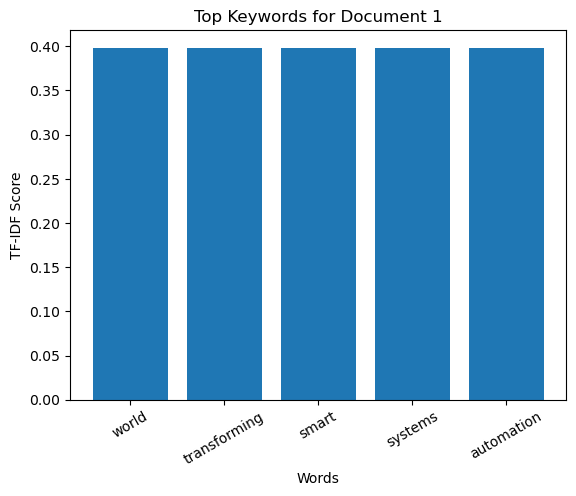

In [12]:
# ============================================
# STEP 8: Visualization (Bar Graph)
# ============================================
doc_index = 0  # Change this (0 to 4) for different documents

scores = tfidf_matrix.toarray()[doc_index]
words = feature_names

# Get top 5 words
top_indices = scores.argsort()[::-1][:5]
top_scores = scores[top_indices]
top_words = [words[i] for i in top_indices]

plt.figure()
plt.bar(top_words, top_scores)
plt.title(f"Top Keywords for Document {doc_index+1}")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=30)
plt.show()